In [1]:
import sys, os
sys.path.append(os.path.abspath("../../"))

# Load shared utilities for attention-from-scratch analysis
from scripts.attention_from_scratch_utils import *

# Set reproducible seed
set_seed(42)

print("Environment ready.")
print("Device:", device)

Environment ready.
Device: mps


# 03a — Positional Information

Transformers do not naturally understand the order of a sequence.  
In this notebook, we explore how positional information is added to token embeddings so the model can reason about *where* each token appears.

### What we'll explore
- Why positional information is necessary
- Sinusoidal positional encodings (hand-crafted waves)
- Visualizing how sinusoidal positions are represented

There are two main ways to represent position in a Transformer —  
**sinusoidal encodings** and **learned positional embeddings**.  
In this notebook, we will explore and understand **sinusoidal encodings**.

# What Is a Sinusoid?

A **sinusoid** is a smooth, wave-like function that repeats over time.  
We mainly use two:

- **Sine wave:** `sin(x)`
- **Cosine wave:** `cos(x)` (the same shape, offset in phase)

Both waves oscillate between **–1 and +1** in a repeating pattern:

peak → valley → peak → valley → …

They behave like gentle rolling ocean waves.

---

# Key Properties of Sinusoids

### **1. Frequency — how fast the wave wiggles**
- **Low frequency:** slow, wide waves  
- **High frequency:** fast, tight waves  

### **2. Amplitude — how tall the wave is**
For positional encodings, this is always **1**.

### **3. Phase — where the wave starts**
Sine and cosine are the same wave but shifted horizontally.

These properties make sinusoids smooth, predictable, and perfect for representing continuous positions.

---

# Everyday Intuition: Why Waves Encode Position

Imagine listening to music with **multiple rhythms** happening at once:

- a slow beat  
- a medium beat  
- a fast beat  

At any moment in the song, the *combination* of beats tells you your exact place —  
even if you never look at a timestamp.

Sinusoidal positional encodings work exactly like this:

- **Slow waves** give a coarse sense of where you are  
- **Fast waves** give fine-grained detail  
- The **combination** gives every position a unique signature  

This is the fundamental intuition behind sinusoidal encodings.

---

# Our Simple 8-Dimensional Positional Encoding

To make this crystal clear, we’ll use **8 dimensions** instead of 512+.

Each dimension carries **one wave** with a different speed:

| **Dimension** | **Intuition**                       |
|---------------|--------------------------------------|
| dim1 (0)      | very slow sine wave                  |
| dim2 (1)      | very slow cosine wave                |
| dim3 (2)      | slow sine wave                       |
| dim4 (3)      | slow cosine wave                     |
| dim5 (4)      | faster sine wave                     |
| dim6 (5)      | faster cosine wave                   |
| dim7 (6)      | very fast sine wave                  |
| dim8 (7)      | very fast cosine wave                |

### Why use waves with different speeds?

Because:

- **Low-index dimensions vary slowly**  
  → capture *broad* positional structure  
- **High-index dimensions vary quickly**  
  → capture *fine* positional details  

Together, they create a rich, multi-scale description of position.

These patterns are **hand-crafted** — not learned — based on the formulas in the original Transformer paper.

---

# Injecting Order Into Embeddings

We add the positional information directly to the token embeddings:

final_embedding = token_embedding + positional_encoding

This enriched embedding tells the model:

- **what** the token represents  
- **where** it appears in the sequence  

This positional signal flows through every attention head,  
letting the Transformer understand structure, order, and long-range relationships.

---

# The Positional Encoding Formula

For each token position `pos` and embedding dimension `i`:

### **Even dimensions (0, 2, 4, …) use sine:**

$$
PE_{\text{pos},\, 2i} = \sin\left( \frac{\text{pos}}{10000^{\frac{2i}{d_{\text{model}}}}} \right)
$$

### **Odd dimensions (1, 3, 5, …) use cosine:**

$$
PE_{\text{pos},\, 2i+1} = \cos\left( \frac{\text{pos}}{10000^{\frac{2i}{d_{\text{model}}}}} \right)
$$

Where:

- **pos** = token position in the sequence (0, 1, 2, 3, …)  
- **i** = index of the sine/cosine pair  
- **dₘₒdₑₗ** = total embedding dimension (e.g., 512)  

---

# What the Formula Does

- The denominator  
  $$10000^{\frac{2i}{d_{\text{model}}}}$$  
  controls the wavelength of each dimension.

- **Low dimensions** (small `i`) → small exponent → slow waves.  
- **High dimensions** (large `i`) → large exponent → fast waves.

This produces a positional encoding vector where each dimension is a wave of a different frequency.

Put all the waves together, and every position gets a **unique multi-frequency signature** the Transformer can use to understand order.

---

<details>
<summary><strong>Click to expand: A Simple, Easy-to-Follow Example of the Math</strong></summary>

<br>

# A Simple, Easy-to-Follow Example of the Math

Let’s walk through a concrete example of how we compute a sinusoidal positional encoding.  
We’ll use **tiny numbers** so it’s crystal clear.

---

## Our Setup

Let’s say:

- The model dimension is:  
  **$d_{\text{model}} = 8$**
- We want the positional encoding for:  
  **position = 3**
- We’ll compute values for the first **four** dimensions:  
  dims: 0, 1, 2, 3  
  (two even → sine; two odd → cosine)

---

# Step 1 — Compute the frequency denominator

The formula uses:

$10000^{\frac{2i}{d_{\text{model}}}}$

Let’s compute this for each dimension.

### Dimension 0 (i = 0)
$10000^{\frac{0}{8}} = 10000^0 = 1$

### Dimension 1 (still i = 0, but cosine)
Same denominator as dim 0:
$10000^{0} = 1$

### Dimension 2 (i = 1)
$10000^{\frac{2}{8}} = 10000^{0.25} = 10$

### Dimension 3 (still i = 1, cosine)
Same denominator:
$10000^{0.25} = 10$

So the denominators for the first 4 dims are:

| Dimension | i | Denominator |
|----------|---|-------------|
| 0        | 0 | 1           |
| 1        | 0 | 1           |
| 2        | 1 | 10          |
| 3        | 1 | 10          |

---

# Step 2 — Compute the input to sin/cos

We compute:

$\frac{\text{pos}}{10000^{\frac{2i}{d_{\text{model}}}}}$

For **position = 3**:

| Dimension | Formula                     | Value   |
|----------|------------------------------|---------|
| 0        | $3 / 1$                      | 3       |
| 1        | $3 / 1$                      | 3       |
| 2        | $3 / 10$                     | 0.3     |
| 3        | $3 / 10$                     | 0.3     |

---

# Step 3 — Apply the sine or cosine

Even dims → sine  
Odd dims → cosine  

| Dimension | Function | Input | Result (approx) |
|----------|----------|--------|------------------|
| 0        | sin      | 3      | 0.1411           |
| 1        | cos      | 3      | −0.9900          |
| 2        | sin      | 0.3    | 0.2955           |
| 3        | cos      | 0.3    | 0.9553           |

---

# Final Positional Encoding (first 4 dims)

For **position = 3**:

[
  0.1411,  
  -0.9900,  
  0.2955,  
  0.9553,  
  … (next dimensions continue the same pattern) …
]

- The **first two values** (dims 0 and 1) come from slow waves  
  because their denominator was *1* → large wavelength  
- The **next two values** (dims 2 and 3) come from faster waves  
  because their denominator was *10* → smaller wavelength  

As we go to higher dimensions:
- the denominator grows  
- the frequency increases  
- the waves get faster  

---

</details>

# Why This Matters

This tiny numerical example shows:

- Early dimensions change slowly → global position  
- Later dimensions change quickly → fine position  
- Together they form a **unique multi-frequency signature** for each position  

This is the core idea behind sinusoidal positional encodings.

---

# How Sinusoidal Encodings Integrate Into a Transformer

Positional encodings are added **before** attention takes place:

(tokens → embedding) + (positions → sinusoidal encoding)
→ combined representation → self-attention → …

This gives the attention layers a coordinate system  
they can use to reason about token order.

---

# Summary — The Intuition Behind Sinusoidal Positional Encodings

- Transformers do not understand order by default  
- Sinusoidal encodings use waves to encode position  
- Each dimension is a wave with a different frequency  
- Slow waves → global information  
- Fast waves → precise information  
- Combined → a unique fingerprint for every position  
- These patterns guide self-attention to understand sequence order  

By the end of this section, you’ll clearly understand how sinusoids give Transformers the ability to reason about **where** tokens are in a sequence.

# Understanding Sinusoidal Positional Encodings (8-D Example)

In this section, we explore sinusoidal positional encodings using a **small 8-dimensional example**.  
Rather than using a short toy sentence, we apply the encoding to a **longer paragraph** from *Alice’s Adventures in Wonderland*.  
This allows us to clearly see how each dimension of the encoding behaves over a real sequence of nearly 200 tokens.

We will:

- visualize **all 8 sinusoidal dimensions**, showing how each frequency band behaves  
- highlight that lower dimensions oscillate quickly, while higher dimensions change very slowly  
- zoom in on two representative dimensions (a sine and a cosine)  
- annotate specific tokens from the paragraph to show how positional encodings map actual text into waves  

These visualizations make the structure of sinusoidal encodings intuitive:  
each position in the sequence receives a unique, multi-frequency pattern that the Transformer can use to understand token order.

In [3]:
text = (
    "Alice was beginning to get very tired of sitting by her sister on the bank, "
    "and of having nothing to do. Once or twice she had peeped into the book her "
    "sister was reading, but it had no pictures or conversations in it, “and what "
    "is the use of a book,” thought Alice, “without pictures or conversation?” "
    "So she was considering in her own mind, as well as she could, whether the "
    "pleasure of making a daisy-chain would be worth the trouble of getting up "
    "and picking the daisies, when suddenly a White Rabbit with pink eyes ran close "
    "by her. There was nothing so very remarkable in that; nor did Alice think it "
    "so very much out of the way to hear the Rabbit say to itself, “Oh dear! Oh dear! "
    "I shall be too late!” "
    "But when the Rabbit actually took a watch out of its waistcoat-pocket, and "
    "looked at it, and then hurried on, Alice started to her feet, for it flashed "
    "across her mind that she had never before seen a rabbit with either a "
    "waistcoat-pocket, or a watch to take out of it."
)

# Simple whitespace tokenization
tokens = text.split()

# Count them
num_tokens = len(tokens)
d_model = 8

tokens[:10], num_tokens

(['Alice',
  'was',
  'beginning',
  'to',
  'get',
  'very',
  'tired',
  'of',
  'sitting',
  'by'],
 188)

In [4]:
import torch
import math

def positional_encoding(max_len: int, d_model: int) -> torch.Tensor:
    positions = torch.arange(max_len).unsqueeze(1)
    dims = torch.arange(0, d_model, 2).unsqueeze(0)

    angle_rates = 1 / (10000 ** (dims / d_model))
    angles = positions * angle_rates

    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles)

    return pe

## Next Step: Generate Fake Token Embeddings

We’ll now create synthetic token embeddings for the tokens in our text and combine them with their positional encodings.  
This will show us **exactly** what the Transformer receives as input before computing attention.

In [5]:
import torch
import pandas as pd
from IPython.display import display, HTML

# -------------------------------------------
# Use ALL tokens
# -------------------------------------------
n = len(tokens)              # number of tokens
selected_tokens = tokens     # use the full list

# -------------------------------------------
# Token Embeddings (fake for demo)
# -------------------------------------------
torch.manual_seed(0)
fake_token_embeds = torch.randn(n, d_model)

df_tokens = pd.DataFrame(
    fake_token_embeds.numpy().round(4),
    columns=[f"dim_{i}" for i in range(d_model)]
)

df_tokens.insert(0, "token", selected_tokens)
df_tokens.insert(1, "position", range(n))

# -------------------------------------------
# Display table
# -------------------------------------------
display(HTML("<h3>1) Token Embeddings (learned via training)</h3>"))
display(df_tokens)

,token,position,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,Alice,0,-1.1258,-1.1524,-0.2506,-0.4339,0.8487,0.6920,-0.3160,-2.1152
1,was,1,0.3223,-1.2633,0.3500,0.3081,0.1198,1.2377,1.1168,-0.2473
2,beginning,2,-1.3527,-1.6959,0.5667,0.7935,0.5988,-1.5551,-0.3414,1.8530
3,to,3,0.7502,-0.5855,-0.1734,0.1835,1.3894,1.5863,0.9463,-0.8437
4,get,4,-0.6136,0.0316,-0.4927,0.2484,0.4397,0.1124,0.6408,0.4412
...,...,...,...,...,...,...,...,...,...,...
183,to,183,0.4818,0.4647,-0.8540,-1.5642,-0.1572,0.9397,-0.1491,-0.1436
184,take,184,3.7251,1.7327,-0.7423,0.1446,0.3173,0.6298,-0.4704,0.2151
185,out,185,-0.4130,-1.8310,-0.0338,0.3661,-0.0235,-0.4511,-2.2000,1.4692
186,of,186,-1.6804,1.1525,1.8086,-1.5669,1.3986,0.2751,-0.3336,-0.6778


In [95]:
pe = positional_encoding(num_tokens, d_model)
pe.shape

torch.Size([188, 8])

## 1. All 8 Positional Encoding Dimensions

The first figure plots **each of the 8 sinusoidal dimensions**, arranged so that:

- **Top row** → all **sine** dimensions (0, 2, 4, 6)  
- **Bottom row** → all **cosine** dimensions (1, 3, 5, 7)

Each dimension corresponds to a different **frequency**, because the formula uses:

$\frac{1}{10000^{2i / d_{\text{model}}}}$

So:

- **Lower dimensions** (0, 1) have **very high frequency** → they oscillate rapidly  
- **Middle dimensions** (2, 3) have **medium frequency**  
- **Higher dimensions** (4, 5, 6, 7) have **very low frequency** → almost straight lines

Each dimension is a smooth sinusoid with a different wavelength.  
Together, they form a rich, multi-scale encoding of position.


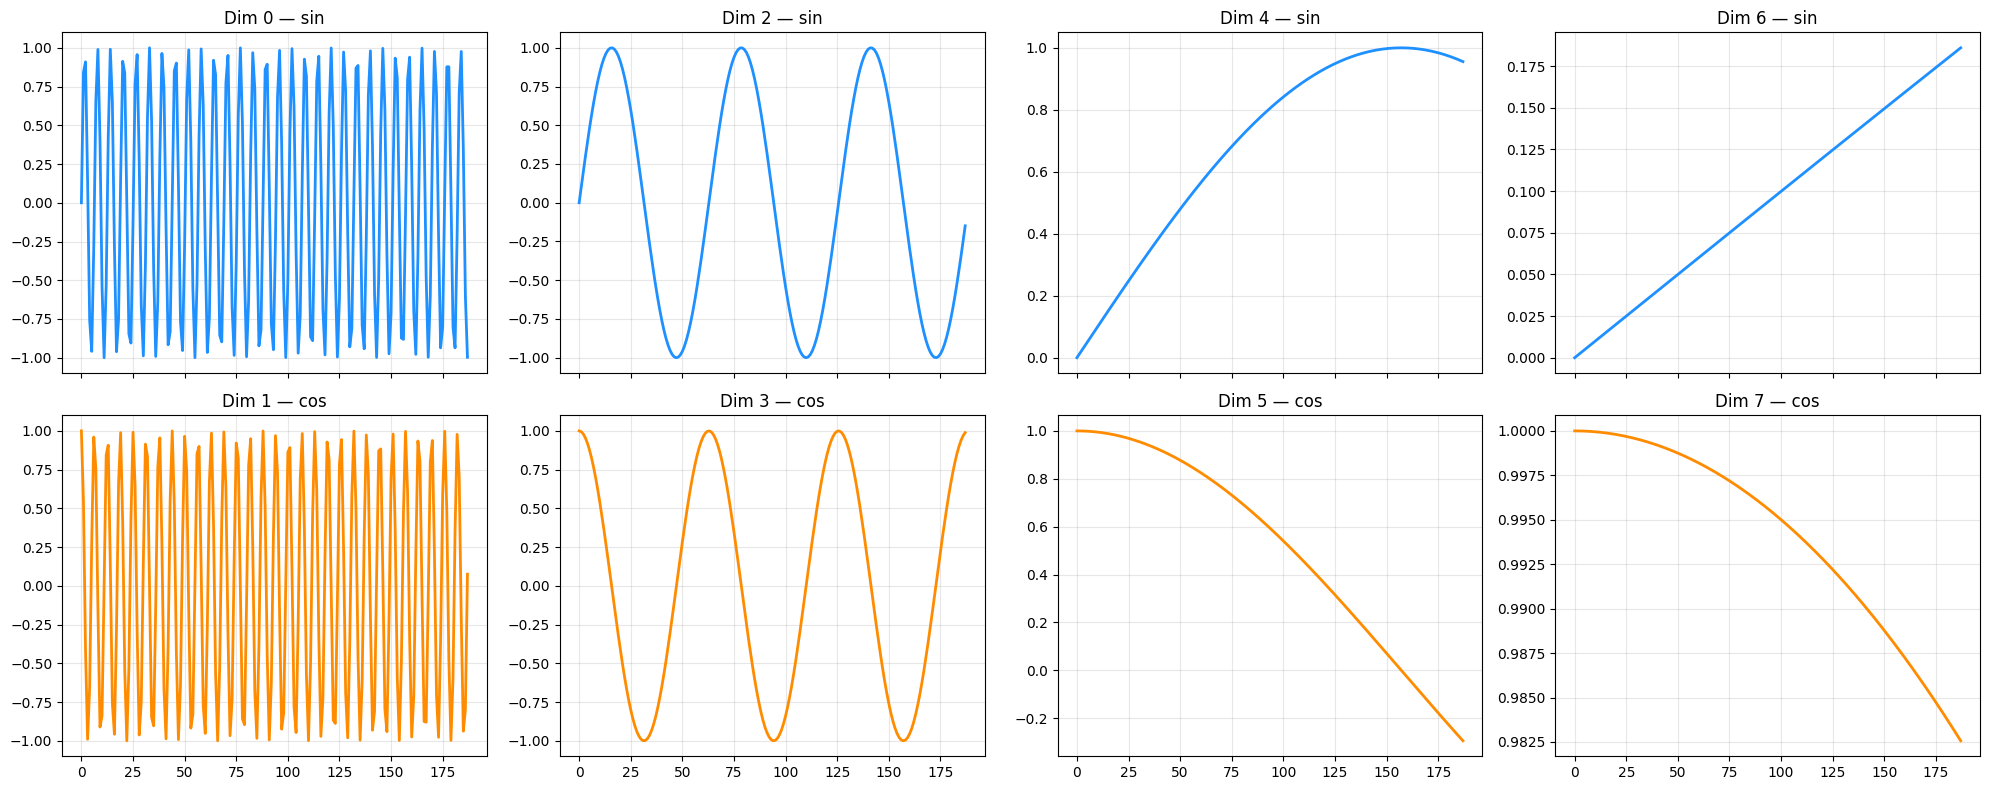

In [96]:
import matplotlib.pyplot as plt

# Prepare figure: 2 rows (sin, cos), 4 columns (dims)
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True)

# Sine dims (even): 0, 2, 4, 6
sin_dims = [0, 2, 4, 6]

# Cosine dims (odd): 1, 3, 5, 7
cos_dims = [1, 3, 5, 7]

# --- Top row: Sine ---
for col, dim in enumerate(sin_dims):
    ax = axes[0, col]
    wave = pe[:, dim]
    ax.plot(wave, color="dodgerblue", linewidth=2)
    ax.set_title(f"Dim {dim} — sin", fontsize=12)
    ax.grid(alpha=0.3)

# --- Bottom row: Cosine ---
for col, dim in enumerate(cos_dims):
    ax = axes[1, col]
    wave = pe[:, dim]
    ax.plot(wave, color="darkorange", linewidth=2)
    ax.set_title(f"Dim {dim} — cos", fontsize=12)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Zooming In: Dimension 2 (sin) and Dimension 5 (cos)

To make the idea more intuitive, the next visualization focuses on **two specific dimensions**:

- **Dimension 2** → medium-frequency **sine**  
- **Dimension 5** → slow **cosine**

These two dimensions show very different behaviors:

- Dim 2 completes several smooth waves over the sequence  
- Dim 5 changes slowly and may not complete even half a cycle  

This demonstrates how higher dimensions encode **broader, more global** sense of position,  
while lower dimensions encode **fine-grained** local structure.

---

## 3. Marking Actual Tokens on the Wave

To make the plot concrete, we select four representative tokens from the paragraph:

- the **first** token  
- the token at **25%** of the paragraph  
- the token at **50%** of the paragraph  
- the token at **80%** of the paragraph  

These tokens are plotted on both dim 2 and dim 5:

- Small **blue** markers show their values on the sine wave  
- Small **orange** markers show their values on the cosine wave  
- Vertical guide lines align the markers to their positions  
- Labels include both the token text and its index

This clearly shows how **the same token position is represented differently**  
in different dimensions of the positional encoding.

---

## Why This Matters

These visualizations highlight the core intuition behind sinusoidal encodings:

- Each position gets a **unique pattern** across all 8 dimensions  
- Lower dimensions encode **fine detail**, higher dimensions encode **coarse location**  
- Sine and cosine pairs let the model recover **relative distances**  
- The entire encoding is **smooth**, allowing attention to learn distance relationships continuously

This is what gives Transformers the ability to understand **where** tokens are—  
without relying on recurrence or convolution.

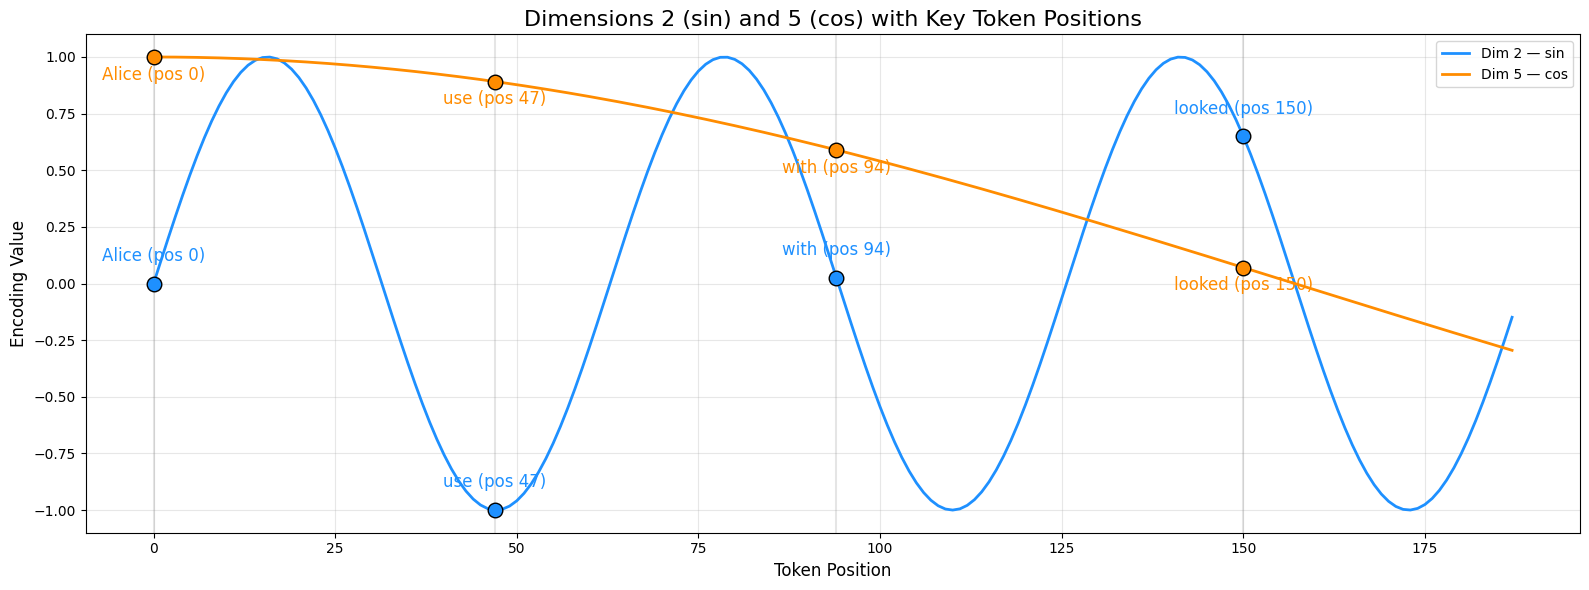

In [97]:
import matplotlib.pyplot as plt

# Pick which dimensions to show
dims_to_plot = [2, 5]   # dim 2 = sin, dim 5 = cos

# Compute key positions
pos_0   = 0
pos_25  = int(num_tokens * 0.25)
pos_50  = int(num_tokens * 0.50)
pos_80  = int(num_tokens * 0.80)

key_positions = {
    tokens[pos_0]: pos_0,
    tokens[pos_25]: pos_25,
    tokens[pos_50]: pos_50,
    tokens[pos_80]: pos_80
}

# Colors for each dimension
dim_colors = {
    2: "dodgerblue",   # sin
    5: "darkorange"    # cos
}

plt.figure(figsize=(16, 6))

# Plot both dimensions
for dim in dims_to_plot:
    wave = pe[:, dim]
    plt.plot(
        wave,
        color=dim_colors[dim],
        linewidth=2,
        label=f"Dim {dim} — {'sin' if dim % 2 == 0 else 'cos'}"
    )

# Label + axis
plt.title("Dimensions 2 (sin) and 5 (cos) with Key Token Positions", fontsize=16)
plt.xlabel("Token Position", fontsize=12)
plt.ylabel("Encoding Value", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# Annotate selected words
for token, idx in key_positions.items():
    y2 = pe[idx, 2]
    y5 = pe[idx, 5]

    # Draw vertical line for reference
    plt.axvline(idx, color="gray", alpha=0.2)

    # Mark on Dim 2
    plt.scatter(idx, y2, color="dodgerblue", s=110, edgecolor="black", zorder=4)
    plt.text(
        idx,
        y2 + 0.1,
        f"{token} (pos {idx})",
        fontsize=12,
        color="dodgerblue",
        ha="center"
    )

    # Mark on Dim 5
    plt.scatter(idx, y5, color="darkorange", s=110, edgecolor="black", zorder=4)
    plt.text(
        idx,
        y5 - 0.1,
        f"{token} (pos {idx})",
        fontsize=12,
        color="darkorange",
        ha="center"
    )

plt.tight_layout()
plt.show()

## How Positional Encodings Apply to Each Token

Before we look at the full positional encoding matrix, it's important to understand what happens at the level of **a single token**.

Every token in a Transformer is represented as a vector of some fixed size — for example:

- If `d_model = 8`, each token is an **8-dimensional vector**
- If `d_model = 512`, each token is a **512-dimensional vector**
- and so on

This means every token has **one value per dimension**.

---

## Positional Encodings Follow the Same Rule

Positional encodings also have **one value per dimension**.

So if your embedding dimension is 8, then **each token receives 8 positional encoding values** —  
because there are 8 dimensions to fill.

You can think of it like this:

Nothing changes the dimensionality; we simply *add* the positional encoding to the token embedding.

---

## One Wave per Dimension

Each dimension of the positional encoding comes from a **different sine or cosine wave**:

- dim 0 → sin wave (fast)
- dim 1 → cos wave (fast)
- dim 2 → sin wave (medium)
- dim 3 → cos wave (medium)
- dim 4 → sin wave (slow)
- dim 5 → cos wave (slow)
- dim 6 → sin wave (very slow)
- dim 7 → cos wave (very slow)

Because there are 8 dimensions, each token gets **8 numbers**, one from each wave.

---

## Key Insight

### **Every token receives the same number of positional encoding values as there are dimensions.**

- A token in an 8-dimensional model gets **8** positional values  
- A token in a 512-dimensional model gets **512** positional values  

Each value comes from evaluating a sine or cosine function at the token’s position.

This gives every token a **unique multi-frequency signature** that represents *where it appears* in the sequence.

---

## Summary

- Tokens live in an *embedding space* of size `d_model`  
- Positional encodings have the **same dimensionality**  
- Each token gets **one positional value per dimension**  
- So yes — each token receives **as many positional encoding values as there are embedding dimensions**

This is exactly how order information gets woven into a Transformer’s internal representations.

In [98]:
import pandas as pd
from IPython.display import HTML, display

# -------------------------------------------
# Select tokens to display (first 4)
# -------------------------------------------
n = 4
selected_tokens = tokens[:n]

# Positional encodings for these tokens
selected_pe = pe[:n]   # shape: (4, d_model)

# -------------------------------------------
# Build a clean dataframe
# -------------------------------------------
df = pd.DataFrame(
    selected_pe.numpy(),
    columns=[f"dim_{i}" for i in range(d_model)]
)

df.insert(0, "token", selected_tokens)
df.insert(1, "position", range(n))


# -------------------------------------------
# Styling: color even dims (sin) & odd dims (cos)
# -------------------------------------------
def highlight_sin_cos(column):
    """
    Highlight dimensions:
    - Even dimensions (sin)  → light blue
    - Odd dimensions (cos)   → light orange
    """
    if column.name.startswith("dim_"):
        dim = int(column.name.split("_")[1])
        if dim % 2 == 0:
            return ['background-color: #cce6ff'] * len(column)   # sine
        else:
            return ['background-color: #ffe0b3'] * len(column)   # cosine

    return [''] * len(column)


styled_df = df.style.apply(highlight_sin_cos, axis=0)


# -------------------------------------------
# Display with a color key
# -------------------------------------------
color_key_html = """
<div style="padding:8px; font-size:14px;">
    <b>Color Key:</b>
    <div style="display:flex; gap:25px; margin-top:6px;">
        <div style="display:flex; align-items:center;">
            <div style="width:20px; height:20px; background:#cce6ff; border:1px solid #888; margin-right:6px;"></div>
            <span>Sine Dimensions (even)</span>
        </div>
        <div style="display:flex; align-items:center;">
            <div style="width:20px; height:20px; background:#ffe0b3; border:1px solid #888; margin-right:6px;"></div>
            <span>Cosine Dimensions (odd)</span>
        </div>
    </div>
</div>
"""

display(HTML(color_key_html))
styled_df

,token,position,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,Alice,0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,was,1,0.841471,0.540302,0.099833,0.995004,0.010000,0.999950,0.001000,1.000000
2,beginning,2,0.909297,-0.416147,0.198669,0.980067,0.019999,0.999800,0.002000,0.999998
3,to,3,0.141120,-0.989992,0.295520,0.955337,0.029995,0.999550,0.003000,0.999996


## Combining Token Embeddings with Positional Encodings  
### (Why We Need Both, and Why We'll Use Fake Embeddings)

Up to this point, we’ve explored **positional encodings** on their own.  
We’ve seen how sinusoidal waves give each token a unique pattern based on its position in the sequence.

But in a real Transformer, tokens do not enter the model with *just* positional information.  
Every token also has a **token embedding** — a learned vector that represents what the token *means* in the language.

#### What Are Token Embeddings?

During training, the model learns a large embedding matrix that maps every word (or subword) to a vector of size `d_model`.

For example:

| Token   | Example Embedding (8-dim)        |
|---------|-----------------------------------|
| Alice   | `[0.12, -0.44, 1.03, …]`          |
| Rabbit  | `[-0.22, 0.90, 0.11, …]`          |
| book    | `[0.55, 0.07, -0.88, …]`          |

These vectors capture **semantic information**  
(similar words have similar embeddings).

#### What Are Positional Encodings?

Positional encodings do **not** represent meaning.  
They only encode **where** a token appears:

| Position | Positional Encoding (example form)                         |
|----------|-------------------------------------------------------------|
| 0        | `[sin(0), cos(0), sin(0), cos(0), …]`                       |
| 1        | `[sin(freq₁), cos(freq₁), sin(freq₂), cos(freq₂), …]`       |
| 2        | `[sin(2·freq₁), cos(2·freq₁), sin(2·freq₂), cos(2·freq₂), …]` |

Each dimension is a point on a sine or cosine wave.

---

## Why We Add Them Together

Token embeddings give us:  
**what the token is**

Positional encodings give us:  
**where the token is**

The Transformer needs **both** pieces of information, so it simply adds the vectors:

$\text{final\_embedding} \;=\; \text{token\_embedding} \;+\; \text{positional\_encoding}$

This final embedding is what gets passed into the attention mechanism to compute **Q**, **K**, and **V**.

---

## Why We Use *Fake* Token Embeddings in This Notebook

Real token embeddings are:

- high-dimensional (512–1024)
- learned during training  
- not easy to understand intuitively

For teaching purposes, we’ll create **simple 8-dimensional fake token embeddings**.  
This lets us:

- visually inspect all dimensions  
- easily see how positional encodings modify the embeddings  
- understand what the final input to attention looks like

These fake embeddings will behave just like real ones,  
but in a format small enough to study in detail.

---

In [100]:
# -------------------------------------------
# Positional Encodings (for ALL tokens)
# -------------------------------------------
selected_pe = pe[:n]     # n = len(tokens) from the first cell

df_positions = pd.DataFrame(
    selected_pe.numpy().round(4),
    columns=[f"dim_{i}" for i in range(d_model)]
)
df_positions.insert(0, "token", selected_tokens)
df_positions.insert(1, "position", range(n))

# -------------------------------------------
# Final = token_emb + pos_enc
# -------------------------------------------
combined = fake_token_embeds + selected_pe

df_combined = pd.DataFrame(
    combined.numpy().round(4),
    columns=[f"dim_{i}" for i in range(d_model)]
)
df_combined.insert(0, "token", selected_tokens)
df_combined.insert(1, "position", range(n))


# -------------------------------------------
# Show first 5 and last 5 only
# -------------------------------------------
def head_tail(df, k=5):
    """Return first k and last k rows (full df if small)."""
    if len(df) <= 2 * k:
        return df
    return pd.concat([df.head(k), df.tail(k)])


# -------------------------------------------
# Color coding functions
# -------------------------------------------
def style_sin_cos(df):
    """Color even dims blue (sin) and odd dims orange (cos)."""
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        if col.startswith("dim_"):
            dim = int(col.split("_")[1])
            if dim % 2 == 0:
                styles[col] = "background-color: #cce6ff"  # sine
            else:
                styles[col] = "background-color: #ffe0b3"  # cosine
    return styles

def style_combined(df):
    """Color final embeddings green."""
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        if col.startswith("dim_"):
            styles[col] = "background-color: #d8f5d2"
    return styles


# -------------------------------------------
# Color Legend
# -------------------------------------------
legend_html = """
<div style='padding:10px; font-size:14px;'>
<b>Color Legend:</b>
<ul>
  <li><span style="background:#cce6ff; padding:3px 8px; border:1px solid #aaa;"></span> Sine Dims (even)</li>
  <li><span style="background:#ffe0b3; padding:3px 8px; border:1px solid #aaa;"></span> Cosine Dims (odd)</li>
  <li><span style="background:#d8f5d2; padding:3px 8px; border:1px solid #aaa;"></span> Final Embedding (token + position)</li>
</ul>
</div>
"""
display(HTML(legend_html))


# -------------------------------------------
# Display tables 2 & 3 (head + tail)
# -------------------------------------------
display(HTML("<h3>2) Positional Encodings (sinusoidal)</h3>"))
display(head_tail(df_positions).style.apply(style_sin_cos, axis=None))

display(HTML("<h3>3) Final Embeddings (Token + Position)</h3>"))
display(head_tail(df_combined).style.apply(style_combined, axis=None))

,token,position,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,Alice,0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,was,1,0.841500,0.540300,0.099800,0.995000,0.010000,1.000000,0.001000,1.000000
2,beginning,2,0.909300,-0.416100,0.198700,0.980100,0.020000,0.999800,0.002000,1.000000
3,to,3,0.141100,-0.990000,0.295500,0.955300,0.030000,0.999600,0.003000,1.000000
4,get,4,-0.756800,-0.653600,0.389400,0.921100,0.040000,0.999200,0.004000,1.000000
183,to,183,0.708700,0.705500,-0.522300,0.852800,0.966600,-0.256300,0.182000,0.983300
184,take,184,0.976600,-0.215100,-0.434600,0.900600,0.964000,-0.266000,0.183000,0.983100
185,out,185,0.346600,-0.938000,-0.342500,0.939500,0.961300,-0.275600,0.183900,0.982900
186,of,186,-0.602000,-0.798500,-0.247000,0.969000,0.958500,-0.285200,0.184900,0.982800
187,it.,187,-0.997200,0.075200,-0.149000,0.988800,0.955600,-0.294800,0.185900,0.982600


,token,position,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,Alice,0,-1.125800,-0.152400,-0.250600,0.566100,0.848700,1.692000,-0.316000,-1.115200
1,was,1,1.163700,-0.723000,0.449800,1.303100,0.129800,2.237600,1.117800,0.752700
2,beginning,2,-0.443400,-2.112100,0.765300,1.773600,0.618800,-0.555300,-0.339400,2.853000
3,to,3,0.891300,-1.575500,0.122100,1.138800,1.419400,2.585900,0.949300,0.156300
4,get,4,-1.370400,-0.622100,-0.103300,1.169500,0.479700,1.111600,0.644800,1.441100
183,to,183,1.190500,1.170200,-1.376300,-0.711500,0.809300,0.683400,0.032800,0.839700
184,take,184,4.701700,1.517600,-1.176800,1.045300,1.281300,0.363800,-0.287500,1.198200
185,out,185,-0.066400,-2.769000,-0.376300,1.305600,0.937800,-0.726600,-2.016100,2.452100
186,of,186,-2.282500,0.354000,1.561700,-0.597900,2.357000,-0.010100,-0.148700,0.305000
187,it.,187,0.292300,0.574000,-0.678200,1.095500,-0.016300,-0.069500,-0.440800,2.643400


## Next Step: Into Self-Attention

Once we have the **final embeddings** (token meaning + positional encoding), the Transformer sends them into three learned linear projections to create:

- **Queries (Q)**
- **Keys (K)**
- **Values (V)**

These are computed as:

$Q = XW_Q \;,\quad K = XW_K \;,\quad V = XW_V$

where $X$ is our final embedding matrix.

Q, K, and V are then used in **scaled dot-product attention**, which tells the model **how strongly each token should attend to every other token**.

This is the step where the Transformer starts to build meaningful relationships between words.